In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
cpi = pd.read_csv("../data/raw/cpi_canada.csv")

unemployment = pd.read_csv("../data/raw/unemployment_canada.csv")

interest = pd.read_csv("../data/raw/interest_rate_canada.csv")

In [4]:
cpi = cpi.rename(columns={
    "observation_date": "Date",
    "CPALCY01CAM661N": "CPI"
})

unemployment = unemployment.rename(columns={
    "observation_date": "Date",
    "LRUNTTTTCAM156S": "Unemployment"
})

interest = interest.rename(columns={
    "observation_date": "Date",
    "IRSTCB01CAM156N": "InterestRate"
})

In [5]:
cpi["Date"] = pd.to_datetime(cpi["Date"])

unemployment["Date"] = pd.to_datetime(unemployment["Date"])

interest["Date"] = pd.to_datetime(interest["Date"])

In [8]:
df = pd.merge(
    cpi,
    unemployment,
    on="Date"
)

df = pd.merge(
    df,
    interest,
    on="Date"
)

df.head()

,Date,CPI,Unemployment,InterestRate
0,1961-01-01,13.428804,7.6,3.47
1,1961-02-01,13.428804,7.7,3.11
2,1961-03-01,13.377873,7.6,3.46
3,1961-04-01,13.343919,7.6,3.57
4,1961-05-01,13.259034,7.6,3.42


In [9]:
df["Inflation"] = df["CPI"].pct_change() * 100

df = df.dropna()

In [11]:
df.head()

,Date,CPI,Unemployment,InterestRate,Inflation
1,1961-02-01,13.428804,7.7,3.11,0.000000
2,1961-03-01,13.377873,7.6,3.46,-0.379267
3,1961-04-01,13.343919,7.6,3.57,-0.253807
4,1961-05-01,13.259034,7.6,3.42,-0.636132
5,1961-06-01,13.309965,7.4,2.80,0.384123


In [12]:
X = df[["Unemployment", "InterestRate"]]

y = df["Inflation"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[-0.03, 0.05]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['Unemployment','InterestRate']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.256
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [19]:
predictions = model.predict(X_test)

In [20]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
rmse = np.sqrt(mse)

In [17]:
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.3339651661793413
MSE: 0.19790653100447256
RMSE: 0.44486686885457377
R²: 0.08872251535679021


## Model Comparison

### Model 1
Feature:
- `Unemployment`

`R²`: -0.00175

---

## Model 2
Features:
- `Unemployment`
- `Interest Rate`

`R²`: 0.0887

Adding interest rates provides the model with additional economic information. Comparing the two R² scores, the more feature added gives a better R² scores, improve the predictions.

## 2. Graphs

#### - Actual vs Predict

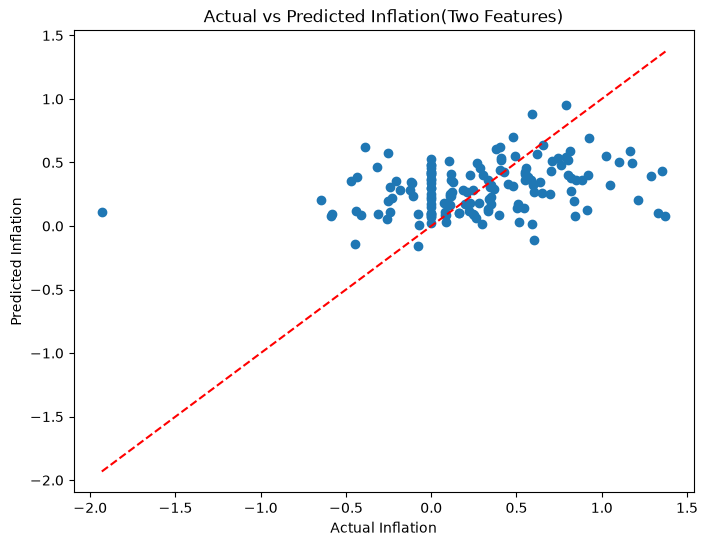

In [21]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, predictions)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Inflation")

plt.ylabel("Predicted Inflation")

plt.title("Actual vs Predicted Inflation(Two Features)")

plt.savefig("../images/actual_vs_predicted_two_features.png", dpi=300)

plt.show()

#### - interest rate vs inflation

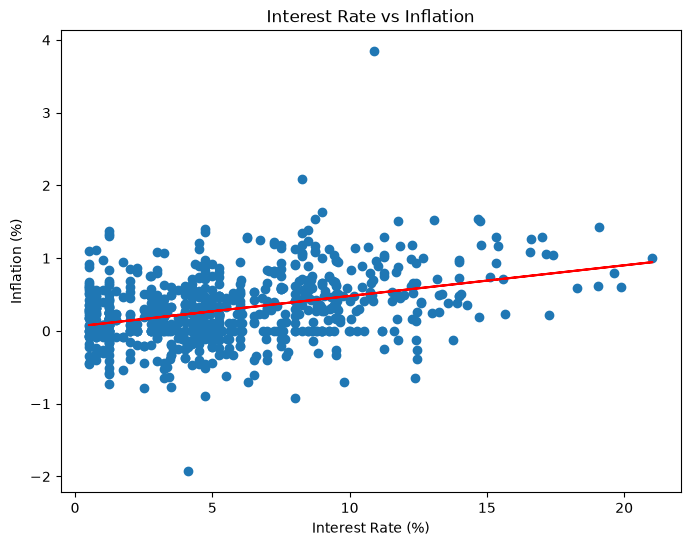

In [22]:
plt.figure(figsize=(8,6))

plt.scatter(df["InterestRate"], df["Inflation"])

m, b = np.polyfit(df["InterestRate"], df["Inflation"], 1)

plt.plot(
    df["InterestRate"],
    m * df["InterestRate"] + b,
    color="red"
)

plt.xlabel("Interest Rate (%)")
plt.ylabel("Inflation (%)")
plt.title("Interest Rate vs Inflation")

plt.savefig("../images/interest_rate_vs_inflation.png", dpi=300)

plt.show()

### Multiple Linear Regression

The baseline model used only the unemployment rate to predict inflation.

To improve the model, the interest rate was added as a second feature.

This allows the model to use more economic information when predicting inflation. And the plot shows interest rate have a much stronger correlation with inflation.

### Actual vs Predicted Inflation

The scatter plot compares the model's predicted inflation values with the actual observed inflation values(with tew features)

If the model were perfectly accurate, all points would lie on the red line, but the wide spread of the points indicates that only unemployment and interest rate have weak predictive power for monthly inflation, which is consistent with the low R² score.